## Welcome to E-tivity 1, Task 1

Your Name:  Irene Esquivel Canaviri

Your Student ID Number: 25369679

### Objective:
Explore the use of bonds yields as a barometer for 'risk' over different term structures, and explore the difference between 'market rates' and 'risk-free rates'.

### Background Information

In Lecture 2 we met the concept of a 'risk-free rate' and a 'market reference rate'. The former are offered by high credit-quality governments (and so have a minimal risk of defaulting), while the latter involve exchanges of money between institutional participants in financial markets (e.g. banks, corporates, municipalities). Depending on the size and financial stability of the firms involved, the rates on these exchanges of money can reach near 'risk-free rate' levels, but a <u>credit risk premium</u> will always persist. This difference is known as the **credit spread**. We also saw in Lecture 2 that these rates (and by extension, the credit spread) acts as a barometer for perceived risk in financial markets.

E-tivity 1, Task 1 will explore these dynamics. Using the Federal Reserve Economic Database (FRED), we will extract yields (rates of return on investment) associated with bonds issued by high credit-quality companies, both over time and for different times to maturity. We will also extract the yields associated with bonds issued by the US Government over time and for different times to maturity. We will then compare how one set of yields relate to the other.

## 1. Library Requirements

Install required libraries and import required packages and modules:




In [29]:
!pip install jupyter requests pandas pip-system-certs

In [19]:
# Import packages and modules
import requests # (module)
import pandas as pd # (package)

## 2. E-tivity Actions

## Task 1

### Objective
*Sign up for a FRED account and generate an API key to extract data directly from FRED.*

#### Task Breakdown:
1. Navigate to `https://fred.stlouisfed.org/` --> `Create New Account`. For the box asking `In what context do you use FRED?`, select 'Student'.
2. Once the account is created: `My Account` --> `API Keys` --> `+ Request API Key`. In the `Describe the application or program you intend to write` field, type 'Student project involving the analysis of corporate bond yields and Treasury yields'. You will then be issued an API key.
    - The API key is a 32-digit alphanumeric code granting you access to the economic database. The code is unique to your account, so do not share the key you receive.
3. Run the below code to ensure the API is working.


#### Further details
A closer inspection of the URL in the <u>get</u> request will reveal you will you be using your API key to extract Consumer Price Index data in JSON format. The `series_ID` for this set of data is `CPIAUCSL`, which can be found in the title of the time series on the relevant webpage (https://fred.stlouisfed.org/series/CPIAUCSL). These are parameters you will be amending in the next task.

In [20]:
# Import or assign API key
'''
Get test observation data from the FRED API
'''

# your API key will look like 'abcdefghijklmnopqrstuvwxyz123456'




response = requests.get(
    'https://api.stlouisfed.org/fred/series/observations?series_id=CPIAUCSL&api_key=5b05a1ce1af785cf7ef2d184a493995d&file_type=json')
pd.DataFrame(response.json()['observations'])


,realtime_start,realtime_end,date,value
0,2026-01-13,2026-01-13,1947-01-01,21.48
1,2026-01-13,2026-01-13,1947-02-01,21.62
2,2026-01-13,2026-01-13,1947-03-01,22.0
3,2026-01-13,2026-01-13,1947-04-01,22.0
4,2026-01-13,2026-01-13,1947-05-01,21.95
...,...,...,...,...
943,2026-01-13,2026-01-13,2025-08-01,323.364
944,2026-01-13,2026-01-13,2025-09-01,324.368
945,2026-01-13,2026-01-13,2025-10-01,.
946,2026-01-13,2026-01-13,2025-11-01,325.031


In [21]:
# Define the FRED API url - this link will be used throughout the Python Notebook.
url = 'https://api.stlouisfed.org/fred/series/observations'

## Task 2

Now that you got your API key working, your next task is to create a function that is flexible enough to import any set of data available on the FRED, over different time frames and for different periodicities.

### Objective
*Create a function that requests economic data from FRED in JSON format given multiple parameters, and output the data in a `pandas DataFrame` format.*

#### Task Breakdown:
1. Create a `for` loop that cycles through a list of series IDs and requests data according to the input parameters
2. Extract the `'observations'` stored in the JSON data from the `response` to the request, and convert it to a `pandas DataFrame`.
3. From the `pandas DataFrame` containing the observations, extract the `values` column and merge it to the `data_series` list.

#### Further details
Based on the dates provided in the `daily_rates` dataframe, discern the number of calendar days between each successive overnight rate, so that it's relative 'influence' in the compounding formula can be more accurately assessed.

For Step...

*1. Two guides:*

- Use `range` and `len` to set the number of loop cycles.

- Consult the FRED API documentation for `fred/series/observations` to determine the appropriate string names for the final 3 parameters.

*3. The `.append` method may be the most appropriate method to use.*

In [22]:
"""
Passes in a series of input parameters for extracting economic data from FRED, and outputs a dataframe containing a number of different data series observed on the same dates.

Parameters
---------
url : string
    The URL to collect data observations for a specified series of data.
list_of_series_IDs : list
    A list of strings containing all the IDs of the data series to extract from FRED.
api_key : string
    API key for FRED data extraction.
start_date : string
    Start date for data extraction. Must be specified in 'YYYY-MM-DD' format.
end_date : string
    End date for data extraction. Must be specified in 'YYYY-MM-DD' format.
daily_frequency : string
    Short code describing the periodicity of the data requested (daily, weekly, monthly, etc.).

Returns
-------
dataframe_series : df
    A dataframe containing the data values for the list of series IDs, merged by date.
"""

def FRED_data_extraction(url, list_of_series_IDs, api_key, start_date, end_date, data_frequency):

    data_series = []
    ##### ** YOUR CODE STARTS HERE ** #####
    for i in range(len(list_of_series_IDs)):

        series_parameters = {
            'series_id': list_of_series_IDs[i],
            'api_key': api_key,
            'file_type': 'json',
            'observation_start': start_date,
            'observation_end': end_date,
            'frequency': data_frequency
        }
    ##### ** YOUR CODE ENDS HERE ** #####

        response = requests.get(url, params=series_parameters)

        if response.status_code == 200:  # 200 OK, 400 Bad Request (wrong API key or Series ID), 401 Unauthorized (no permission), 403 Forbidden (wrong URL), 404 Not Found (data unavailable)
    ##### ** YOUR CODE STARTS HERE ** #####
            obs_data = pd.DataFrame(response.json()['observations'])
    ##### ** YOUR CODE ENDS HERE ** #####

        else:
            print('Failed to get data. Status code: {}'.format(response.status_code))

    ##### ** YOUR CODE STARTS HERE ** #####
        data_series.append(obs_data['value'])
    ##### ** YOUR CODE ENDS HERE ** #####

    data_series.append(obs_data['date'])
    dataframe_series = pd.DataFrame(data_series).T
    dataframe_series['date'] = pd.to_datetime(dataframe_series['date'])
    dataframe_series.set_index('date', inplace=True)
    dataframe_series = dataframe_series.astype(float)

    return dataframe_series


In [23]:
##### ** YOUR CODE STARTS HERE ** #####
FRED_data_extraction(
    url,
    ['CPIAUCSL'],
    '5b05a1ce1af785cf7ef2d184a493995d',
    '2024-01-01',
    '2024-12-31',
    'm'
)
##### ** YOUR CODE ENDS HERE ** #####

,value
date,
2024-01-01,309.794
2024-02-01,311.022
2024-03-01,312.107
2024-04-01,313.016
2024-05-01,313.140
2024-06-01,313.131
2024-07-01,313.566
2024-08-01,314.131
2024-09-01,314.851


## Task 3

Use the function created as part of Task 2 to extract Treasury Yield data and Hiqh-quality Market (HQM) Corporate Bond Yield data.

<b>Why HQM data?</b> The HQM Yield Curve is an important metric used by the US Treasury to accurately measure the general level of interest rates in the corporate bond market over different investment horizons. The HQM yield curve is formed by computing the average yield available on over 1,500+ bonds issued by companies in the US over different times to maturity, from 6-months all the way to 30 years. To be included, the bonds must be large (>$250 million) and have a highly reputable credit rating (AAA - A). Given the size of the sample, the time frame being covered, and the restrictive conditions for inclusion in the sample (large and highly-reputable bonds only), the HQM dataset represents a proxy for the expected return on a near risk-free investment in the corporate bond market over different time horizons.

- For more on the HQM Yield Curve, read here: https://home.treasury.gov/system/files/226/ycp_oct2011.pdf

<b>Why Treasury data?</b> The Treasury Yield Curve is an important metric used by the US Treasury to measure the yield available in the US Government Bond market over different investment horizons. Given the size and stability of the US Federal Reserve, and the ubiquity of the US Dollar due to its status as the default 'reserve currency' for global central banks (the dollar represents approx. 58% of foreign reserve holdings worldwide), it is supremely unlikely that the US Government will default on its debts. Therefore, Treasury Yields represent a proxy for the risk-free rate you can earn on your investment by investing your money for different lengths of time. Treasury Bonds can be purchased for a multitude of time horizons, but we will focus our attention on time horizons between 6-months and 30-years.

Measuring the difference between HQM data and the Treasury data highlights the difference between a near risk-free market investment and a risk-free investment in US government bonds. Therefore, the difference between these rates is a barometer for the level of risk that investors *perceive* exists in the wider financial markets at any given moment. This varies over time, and is a dynamic we want to explore.

### Objective
*Use the function created in Task 2 to draw down HQM data and Treasury Yield data.*

#### Task Breakdown:
1. For the period 1st January - 31st December 2024, gather monthly HQM Corporate Bond Spot Rates <b>*and*</b> Treasury Yield data for the following time horizons: 6-months and 1-, 2-, 5-, 7-, 10-, 20-, and 30-years.

#### Further details
*1. The series of IDs must be included as a comma-separated list. The series ID for the 6-month HQM Corporate Bond Spot Rates is `'HQMCB6MT'`, so your list will start off as ['HQMCB6MT', ... ]*

In [ ]:
##### ** YOUR CODE STARTS HERE ** #####
hqm_ids = [
    'HQMCB6MT',   # 6 months
    'HQMCB1YR',   # 1 year
    'HQMCB2YR',   # 2 years
    'HQMCB5YR',   # 5 years
    'HQMCB7YR',   # 7 years
    'HQMCB10YR',  # 10 years
    'HQMCB20YR',  # 20 years
    'HQMCB30YR'   # 30 years
]


treasury_ids = [
    'DGS6MO',   # 6 months
    'DGS1',     # 1 year
    'DGS2',     # 2 years
    'DGS5',     # 5 years
    'DGS7',     # 7 years
    'DGS10',    # 10 years
    'DGS20',    # 20 years
    'DGS30'     # 30 years
]


Corporate_HQM_Data = FRED_data_extraction(
    url,
    hqm_ids,
    '5b05a1ce1af785cf7ef2d184a493995d',   
    '2024-01-01',
    '2024-12-31',
    'm'
)

Treasury_Data = FRED_data_extraction(
    url,
    treasury_ids,
    '5b05a1ce1af785cf7ef2d184a493995d',   
    '2024-01-01',
    '2024-12-31',
    'm'
)
##### ** YOUR CODE ENDS HERE ** #####

col_names = ['6m', '1y', '2y', '5y', '7y', '10y', '20y', '30y']
Corporate_HQM_Data.columns = col_names
Treasury_Data.columns = col_names

## Task 4

### Objective
*Calculate the average monthly spread between the two sets of rates for each term to maturity throughout 2024 and, paying particular attention to the spreads for each term to maturity, answer the following question:*

    - What do the differences in spreads say about the relationship between market and risk-free rates for different time horizons?

#### Further details

To find the set of differences in spreads for 2024, you may complete option 1, 2, or both:

<u>Option 1: Calculation of Mean Average Monthly Spreads:</u>
1. Calculate the monthly spreads between the two sets of rates for each term to maturity, and
2. Average (mean) along `axis=0` of the resulting dataframe to get the mean average spread for each term to maturity.
3. Plot the resulting dataframe.

<u>Option 2: Visual Inspection of Spreads:</u>
1. Average (mean) along axis '0' of the HQM and Treasury Yield dataframes to get the mean average rate for each term to maturity for both sets of rates.
2. Merge the resulting dataframes column-wise (using `pd.concat` along the appropriate axis).
3. Plot the resulting dataframe.

<Axes: title={'center': 'HQM vs Treasury Average Rates (2024)'}>

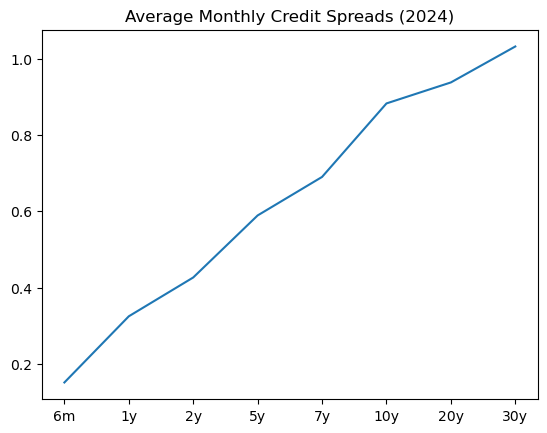

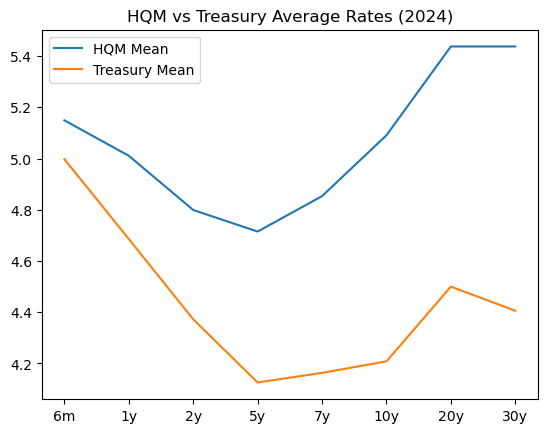

In [26]:
# Option 1:
# Calculate spread: Market Rates minus Risk-free Rates
# Calculate mean spread for each term to maturity for 2024.

##### ** YOUR CODE STARTS HERE ** #####
Spreads = Corporate_HQM_Data - Treasury_Data
spreadsAverage = Spreads.mean(axis=0)
spreadsAverage.plot(title="Average Monthly Credit Spreads (2024)")
##### ** YOUR CODE ENDS HERE ** #####

# Option 2:
# mean along column axis
# merge dataframes column-wise (use 'pd.concat' and appropriate 'axis')

##### ** YOUR CODE STARTS HERE ** #####
hqmMean = Corporate_HQM_Data.mean(axis=0) 
treasuryMean = Treasury_Data.mean(axis=0)

marketRate_vs_riskFreeRate = pd.concat([hqmMean, treasuryMean], axis=1) 
marketRate_vs_riskFreeRate.columns = ['HQM Mean', 'Treasury Mean']
##### ** YOUR CODE ENDS HERE ** #####
marketRate_vs_riskFreeRate.plot(title="HQM vs Treasury Average Rates (2024)")

## Task 5

Task 4 looked at the spreads between market rates and risk-free rates for different time/investment horizons. Our attention now turns to a historic look at the interactions between market risk (HQM) and risk-free investments (Treasury): looking at how individual spreads vary over time. Using the 1-year rate for each set of data, extract monthly HQM and Treasury yields for the period January 1st 2000 - December 31st 2024. Calculate the spreads between the 1-year yields for this 25-year period, and address the following prompt:

    - Paying particular attention to how the dates match up to key global events (financial or otherwise, as discussed in Lecture Slides 2), discuss what the spreads say about the relationship between market and risk-free rates.

### Objective
Calculate and the credit spread for 1-year rates over the period 2000-2024 and discuss its role as a measure of perceived market risk.

#### Further details
Calculating the 1-year credit spread for the period 2000-2024 is similar to the process followed in Task 4, without the need to average rates. You may complete option 1, 2, or both:

<u>Option 1: Calculation of Monthly 1-year Credit Spreads:</u>
1. Calculate the monthly spreads between the two sets of 1-year rates over the period 2000-2024, and
2. Plot the resulting dataframe.

<u>Option 2: Visual Inspection of Spreads:</u>
1. Merge the two dataframes column-wise (using `pd.concat` along the appropriate axis).
2. Plot the resulting dataframe.

<Axes: title={'center': '1-Year Credit Spread (2000–2024)'}, xlabel='date'>

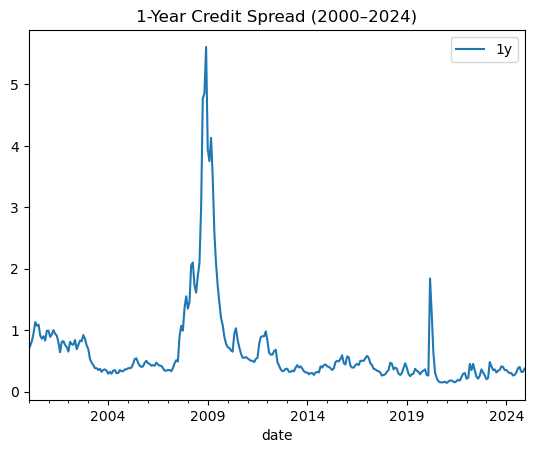

In [28]:
##### ** YOUR CODE STARTS HERE ** #####
Long_term_HQM_Data = FRED_data_extraction(
    url,
    ['HQMCB1YR'],   # 1-year HQM corporate bond rate
    '5b05a1ce1af785cf7ef2d184a493995d',
    '2000-01-01',
    '2024-12-31',
    'm'
)

Long_term_Treasury_Data = FRED_data_extraction(
    url,
    ['DGS1'],       # 1-year Treasury yield
    '5b05a1ce1af785cf7ef2d184a493995d',
    '2000-01-01',
    '2024-12-31',
    'm'
)
##### ** YOUR CODE ENDS HERE ** #####
col_names = ['1y']
Long_term_HQM_Data.columns = col_names
Long_term_Treasury_Data.columns = col_names

##### ** YOUR CODE STARTS HERE ** #####
LT_spreads = Long_term_HQM_Data - Long_term_Treasury_Data
##### ** YOUR CODE ENDS HERE ** #####
LT_spreads.plot(title="1-Year Credit Spread (2000–2024)")